In [114]:

#import sys
!{sys.executable} -m pip install tensorflow-datasets

import sys
#{sys.executable} -m pip install importlib_resources

In [115]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image
import pandas as pd
import seaborn as sb

datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

as_supervised: se refiere a que se van a devolver los datos como tuplas imagen y etiqueta en vez de un diccionario

y with_info se refiere a que devuelve un segundo objeto con metadatos del dataset

In [116]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\herna\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [117]:
datos_entrenamiento, datos_pruebas = datos['train'],datos['test']

In [118]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [119]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes,etiquetas

In [120]:
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

map sirve para aplicar una funcion a cada elemento del dataset, en vez de usar un for que seria mas lento 

In [121]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()


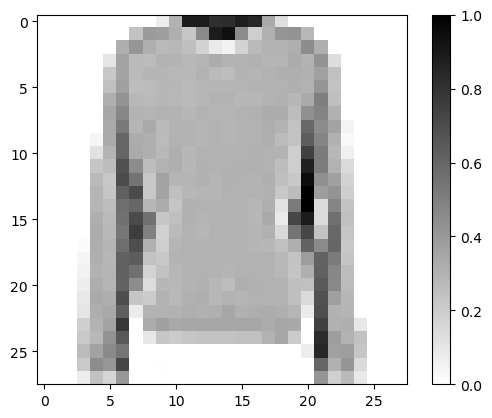

In [122]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28,28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

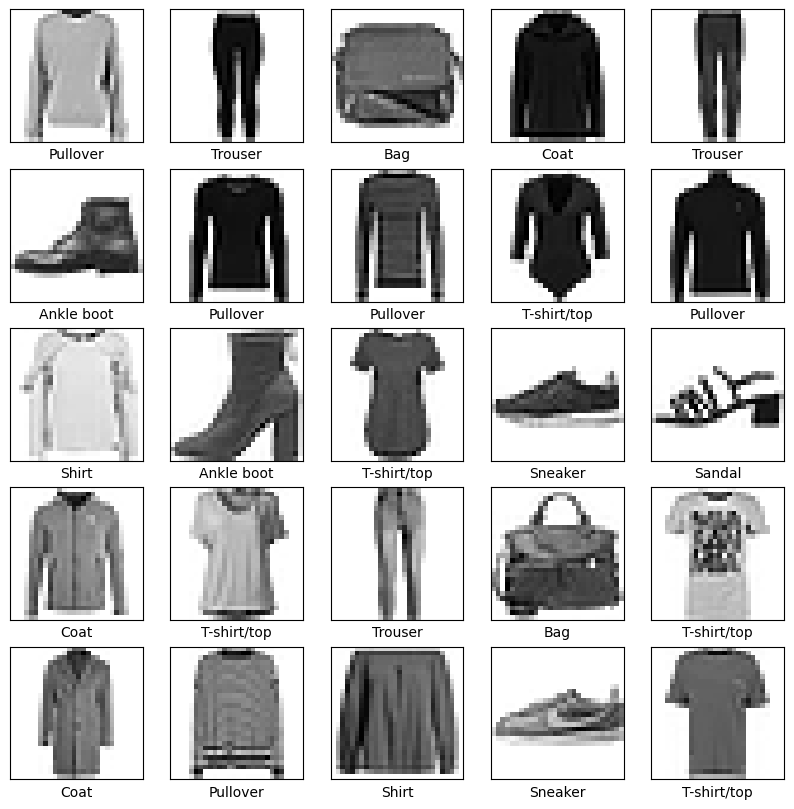

In [123]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen,cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show

In [124]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28,1)),
    tf.keras.layers.Dense(50,activation=tf.nn.relu),
    tf.keras.layers.Dense(50,activation=tf.nn.relu),
    tf.keras.layers.Dense(10,activation=tf.nn.softmax)
])

In [125]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=(['accuracy'])
)

In [126]:
TAMANO_LOTE=32

In [127]:
num_ej_entrenamiento = metadatos.splits['train'].num_examples
num_ej_pruebas = metadatos.splits['test'].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [128]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas= datos_pruebas.batch(TAMANO_LOTE)

In [129]:
historial = model.fit(datos_entrenamiento,epochs=30,steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7577 - loss: 0.6840
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8543 - loss: 0.4033
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 893us/step - accuracy: 0.8721 - loss: 0.3561
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 897us/step - accuracy: 0.8732 - loss: 0.3411
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 892us/step - accuracy: 0.8837 - loss: 0.3167
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step - accuracy: 0.8880 - loss: 0.3017
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8903 - loss: 0.2969
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8978 - loss: 0.2722
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 950us/step - accuracy: 0.8996 - loss: 0.2733
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8999 - loss: 0.2667
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9029 - loss: 0.2576
Epoch 12/30
1875/187

In [144]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = model.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                100*np.max(arr_predicciones),
                                nombres_clases[etiqueta_real]),
                                color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


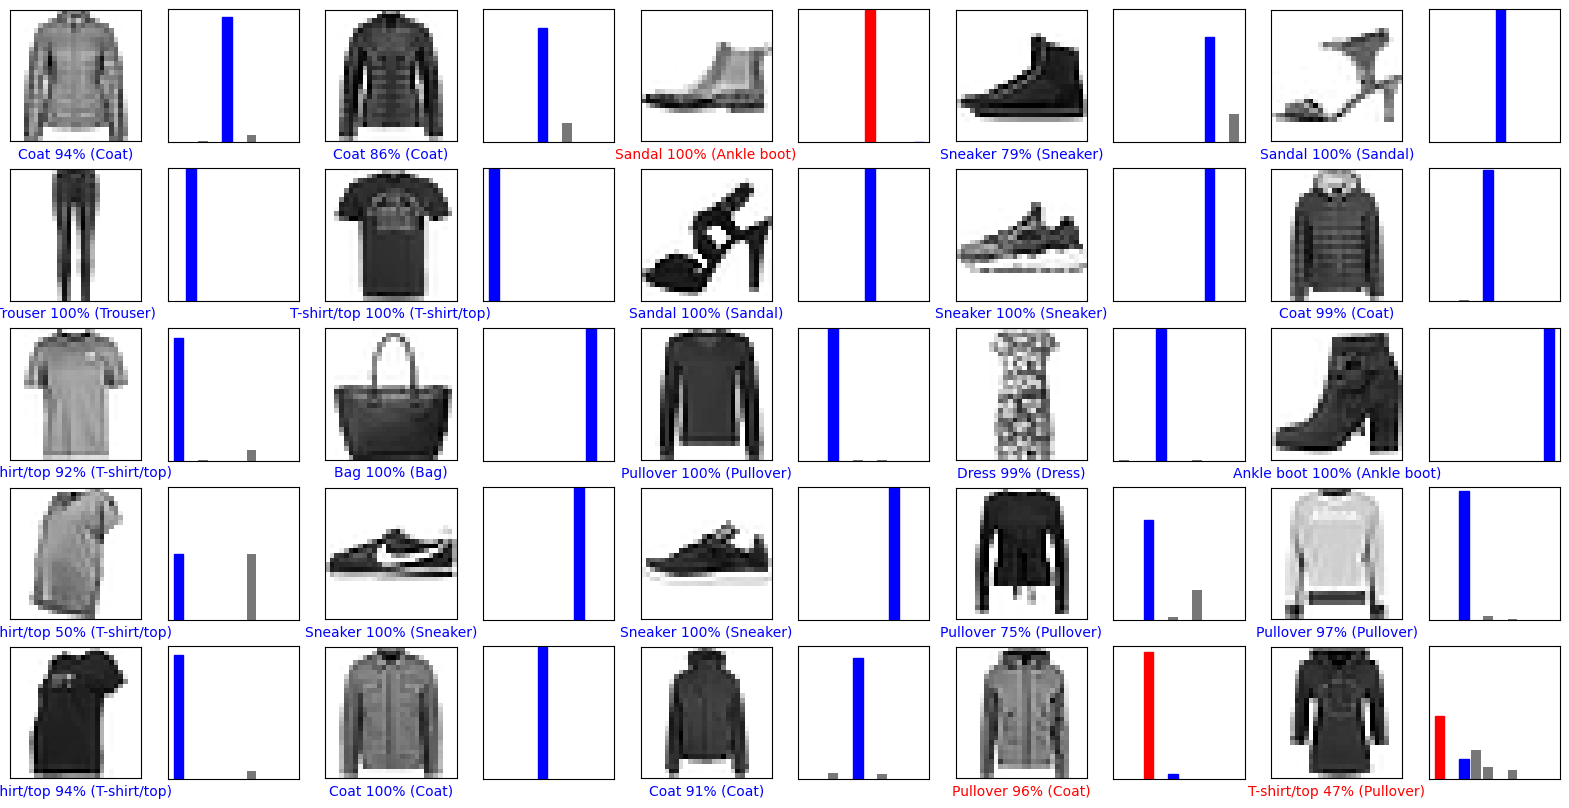

In [145]:
def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


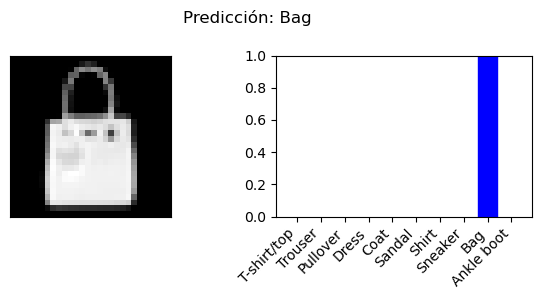

Prediccion: T-shirt/top
Prediccion: Bag


In [169]:
imagen = imagenes_prueba[20]
imagen2 = Image.open('data/images (7).jpg')

imagen2 = imagen2.convert('L')
imagen2 = imagen2.resize((28, 28))
imagen2 = np.array(imagen2)
imagen2 = imagen2 / 255.0
imagen2 = imagen2.reshape(1, 28, 28, 1)

etiqueta2 = 8

imagen = np.array([imagen])
prediccion = model.predict(imagen)
prediccion2 = model.predict(imagen2)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(imagen2[0, ..., 0], cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.grid(False)

plt.subplot(1, 2, 2)
grafica = plt.bar(range(10), prediccion2[0], color="#777777")
plt.xticks(range(10), nombres_clases, rotation=45, ha='right')
plt.ylim([0, 1])
grafica[np.argmax(prediccion2[0])].set_color('red')
grafica[etiqueta2].set_color('blue')

plt.suptitle("Predicción: " + nombres_clases[np.argmax(prediccion2[0])])
plt.tight_layout()
plt.show()

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])
print("Prediccion: " + nombres_clases[np.argmax(prediccion2[0])])

h5 es un formato diseñado para guardar y organizar grandes cantidades de datos, trabaja como una caprta inteligente que guarda los datos en una sestrucutra jerarquica

In [173]:
model.save('C:/Users/herna/Documentos/notebook/actividad_11/data/modelo_fashion.h5')
print("Modelo guardado")

# Verificar que se guardó (opcional)
import os
print(os.path.getsize('C:/Users/herna/Documentos/notebook/actividad_11/data/modelo_fashion.h5'), "bytes")

from keras.models import load_model

model = load_model('C:/Users/herna/Documentos/notebook/actividad_11/data/modelo_fashion.h5')
print("Modelo cargado")

Modelo guardado
540688 bytes


TypeError: Error when deserializing class 'Dense' using config={'name': 'dense_17', 'trainable': True, 'dtype': 'float32', 'units': 10, 'activation': {'module': 'builtins', 'class_name': 'function', 'config': 'softmax_v2', 'registered_name': 'function'}, 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}.

Exception encountered: Could not interpret activation function identifier: {'module': 'builtins', 'class_name': 'function', 'config': 'softmax_v2', 'registered_name': 'function'}

In [175]:
import os

ruta = 'C:/Users/herna/Documentos/notebook/actividad_11/data/modelo_fashion.h5'

if os.path.exists(ruta):
    tamaño = os.path.getsize(ruta) / (1024*1024)  # convertir a MB
    print(f"✅ Archivo existe: {tamaño:.2f} MB")
else:
    print("archivo no encontrado")

✅ Archivo existe: 0.52 MB
